In [16]:
#数据预处理
import pandas as pd

df = pd.read_csv("ecommerce_sales_34500.csv")

df.head()

df.shape

df.info()

df.describe()

df["category"].value_counts()
df["region"].value_counts()
df["payment_method"].value_counts()
df["returned"].value_counts()
df["customer_gender"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  object 
 1   customer_id         34500 non-null  object 
 2   product_id          34500 non-null  object 
 3   category            34500 non-null  object 
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  object 
 8   order_date          34500 non-null  object 
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  object 
 11  returned            34500 non-null  object 
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer_age        34500 non-null  int64  
 16  cust

customer_gender
Female    16818
Male      16310
Other      1372
Name: count, dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df["order_id"].duplicated().sum()

np.int64(0)

In [19]:
df["order_id"].nunique()

34500

In [20]:
df.isnull().sum()

order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

In [21]:
df["order_date"].head(10)

0    2023-12-23
1    2025-04-03
2    2024-10-08
3    2024-09-14
4    2024-12-21
5    2024-04-14
6    2025-05-20
7    2023-09-14
8    2023-10-23
9    2023-10-31
Name: order_date, dtype: object

In [22]:
df["order_date"]=pd.to_datetime(df["order_date"])

In [23]:
df["order_date"].dtype

dtype('<M8[ns]')

In [24]:
df["order_date"].min()

Timestamp('2023-09-12 00:00:00')

In [25]:
df["order_date"].max()

Timestamp('2025-09-11 00:00:00')

In [26]:
df["order_date"].isnull().sum()

np.int64(0)

In [27]:
df["category"].unique()

array(['Home', 'Grocery', 'Electronics', 'Beauty', 'Fashion', 'Toys',
       'Sports'], dtype=object)

In [28]:
df["payment_method"].unique()

array(['Credit Card', 'UPI', 'COD', 'PayPal', 'Debit Card', 'Wallet'],
      dtype=object)

In [29]:
df["region"].unique()

array(['West', 'South', 'North', 'East', 'Central'], dtype=object)

In [30]:
df["returned"].unique()

array(['No', 'Yes'], dtype=object)

In [31]:
df["customer_gender"].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [32]:
categorical_cols = [
    'category',
    'payment_method',
    'region',
    'returned',
    'customer_gender'
]
for col in categorical_cols:
    print(f"\n---{col}---")
    print('类别数量：', df[col].nunique())
    print(df[col].value_counts())


---category---
类别数量： 7
category
Fashion        6254
Electronics    6180
Home           5487
Toys           4247
Sports         4171
Beauty         4103
Grocery        4058
Name: count, dtype: int64

---payment_method---
类别数量： 6
payment_method
Credit Card    12170
Debit Card      8505
COD             4160
UPI             4156
PayPal          3444
Wallet          2065
Name: count, dtype: int64

---region---
类别数量： 5
region
South      7584
North      7572
East       6904
West       6808
Central    5632
Name: count, dtype: int64

---returned---
类别数量： 2
returned
No     32597
Yes     1903
Name: count, dtype: int64

---customer_gender---
类别数量： 3
customer_gender
Female    16818
Male      16310
Other      1372
Name: count, dtype: int64


In [33]:
numeric_cols = [
    "price",
    "discount",
    "quantity",
    "delivery_time_days",
    "total_amount",
    "shipping_cost",
    "profit_margin",
    "customer_age"
]

df[numeric_cols].describe().T 

,count,mean,std,min,25%,50%,75%,max
price,34500.0,119.391632,195.620477,1.01,16.69,45.66,130.9500,2930.47
discount,34500.0,0.049291,0.069894,0.00,0.00,0.00,0.1000,0.30
quantity,34500.0,1.490725,0.932270,1.00,1.00,1.00,2.0000,5.00
delivery_time_days,34500.0,4.814203,1.242141,3.00,4.00,5.00,6.0000,13.00
total_amount,34500.0,170.008494,357.503014,0.82,19.71,56.82,168.5300,12931.80
shipping_cost,34500.0,6.152120,2.389539,0.00,4.42,6.09,7.8300,15.65
profit_margin,34500.0,28.116505,53.352947,-6.20,1.50,10.55,33.1325,1536.17
customer_age,34500.0,43.474377,14.980682,18.00,31.00,43.00,56.0000,69.00


In [34]:
print("price异常：", (df["price"] <= 0).sum())

print(
    "discount异常：",
    ((df["discount"] < 0) | (df["discount"] > 0.3)).sum()
)

print("quantity异常：", (df["quantity"] <= 0).sum())

print(
    "delivery_time_days异常：",
    (df["delivery_time_days"] < 0).sum()
)

print(
    "total_amount异常：",
    (df["total_amount"] < 0).sum()
)

print(
    "shipping_cost异常：",
    (df["shipping_cost"] < 0).sum()
)

print(
    "customer_age异常：",
    ((df["customer_age"] < 18) | (df["customer_age"] > 70)).sum()
)

price异常： 0
discount异常： 0
quantity异常： 0
delivery_time_days异常： 0
total_amount异常： 0
shipping_cost异常： 0
customer_age异常： 0


In [35]:
df.nlargest(10,'price')[
    ['order_id','product_id','category','price','quantity','discount','total_amount']
]

,order_id,product_id,category,price,quantity,discount,total_amount
7705,O107705,P242326,Electronics,2930.47,4,0.0,11721.88
10208,O110208,P214900,Electronics,2653.17,1,0.0,2653.17
20765,O120765,P217031,Electronics,2586.36,5,0.0,12931.80
27798,O127798,P224743,Electronics,2259.66,5,0.0,11298.30
13307,O113307,P237985,Electronics,2211.69,2,0.0,4423.38
7882,O107882,P249108,Electronics,2195.08,1,0.0,2195.08
13524,O113524,P228028,Electronics,2181.20,1,0.0,2181.20
6553,O106553,P247485,Electronics,2143.40,1,0.0,2143.40
24837,O124837,P205853,Electronics,2025.24,1,0.0,2025.24
26281,O126281,P213720,Electronics,1992.86,2,0.1,3587.15


In [36]:
df.nlargest(10, "total_amount")[
    ["order_id", "category", "price",
     "quantity", "discount", "total_amount"]
]

,order_id,category,price,quantity,discount,total_amount
20765,O120765,Electronics,2586.36,5,0.00,12931.80
7705,O107705,Electronics,2930.47,4,0.00,11721.88
27798,O127798,Electronics,2259.66,5,0.00,11298.30
16950,O116950,Electronics,1556.79,4,0.00,6227.16
24728,O124728,Electronics,1540.66,4,0.00,6162.64
29695,O129695,Electronics,1495.73,4,0.00,5982.92
9386,O109386,Electronics,1986.49,3,0.00,5959.47
20690,O120690,Electronics,1064.39,5,0.00,5321.95
25994,O125994,Electronics,1319.20,4,0.00,5276.80
32321,O132321,Electronics,1845.83,3,0.05,5260.62


In [37]:
(df["profit_margin"] < 0).sum()

np.int64(6104)

In [38]:
df[df["profit_margin"] < 0][
    ["order_id", "category", "total_amount",
     "shipping_cost", "profit_margin", "returned"]
].head(10)

,order_id,category,total_amount,shipping_cost,profit_margin,returned
1,O100001,Grocery,24.73,4.60,-2.62,No
7,O100007,Beauty,9.98,4.51,-0.02,No
8,O100008,Fashion,6.28,3.43,-1.23,No
9,O100009,Grocery,10.91,2.76,-1.89,No
12,O100012,Grocery,9.50,4.99,-4.23,No
13,O100013,Toys,7.12,3.35,-0.50,No
28,O100028,Grocery,41.94,4.61,-1.25,No
31,O100031,Grocery,8.77,1.24,-0.54,No
32,O100032,Grocery,7.56,2.06,-1.46,No
34,O100034,Grocery,25.68,6.32,-4.27,No


In [39]:

df["calculated_amount"] = (
    df["price"]
    * df["quantity"]
    * (1 - df["discount"])
)

df["amount_diff"] = (
    df["calculated_amount"] - df["total_amount"]
).abs()

print(df["amount_diff"].describe())

print("金额异常订单数：", (df["amount_diff"] > 0.01).sum())

print(df["delivery_time_days"].value_counts().sort_index())

print(df["returned"].value_counts())

print("亏损订单数：", (df["profit_margin"] < 0).sum())

print("独立用户数：", df["customer_id"].nunique())
print("独立商品数：", df["product_id"].nunique())

count    34500.000000
mean         0.001114
std          0.001587
min          0.000000
25%          0.000000
50%          0.000000
75%          0.002000
max          0.005000
Name: amount_diff, dtype: float64
金额异常订单数： 0
delivery_time_days
3      4907
4     10094
5     10296
6      5961
7      2400
8       663
9       152
10       25
12        1
13        1
Name: count, dtype: int64
returned
No     32597
Yes     1903
Name: count, dtype: int64
亏损订单数： 6104
独立用户数： 7903
独立商品数： 24912


In [40]:
df=df.drop(columns=['calculated_amount','amount_diff'])

In [41]:
df.shape

(34500, 17)

In [42]:
df['year_month']=(df['order_date'].dt.to_period('M').astype(str))

In [43]:
print("数据维度：", df.shape)

print("\n缺失值总数：")
print(df.isnull().sum().sum())

print("\n重复记录数：")
print(df.duplicated().sum())

print("\n订单ID重复数：")
print(df["order_id"].duplicated().sum())

print("\n日期范围：")
print(df["order_date"].min())
print(df["order_date"].max())

print("\n数据类型：")
print(df.dtypes)

数据维度： (34500, 18)

缺失值总数：
0

重复记录数：
0

订单ID重复数：
0

日期范围：
2023-09-12 00:00:00
2025-09-11 00:00:00

数据类型：
order_id                      object
customer_id                   object
product_id                    object
category                      object
price                        float64
discount                     float64
quantity                       int64
payment_method                object
order_date            datetime64[ns]
delivery_time_days             int64
region                        object
returned                      object
total_amount                 float64
shipping_cost                float64
profit_margin                float64
customer_age                   int64
customer_gender               object
year_month                    object
dtype: object


In [76]:
df.to_csv('clean_ecommerce_sales.csv',index=False)

In [77]:
#对清洗后数据进行分析
df= pd.read_csv(
    "clean_ecommerce_sales.csv"
)

df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender,year_month,is_returned
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female,2023-12,False
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male,2025-04,False
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male,2024-10,False
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female,2024-09,False
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male,2024-12,False


In [78]:
df.shape

(34500, 19)

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  object 
 1   customer_id         34500 non-null  object 
 2   product_id          34500 non-null  object 
 3   category            34500 non-null  object 
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  object 
 8   order_date          34500 non-null  object 
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  object 
 11  returned            34500 non-null  object 
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer_age        34500 non-null  int64  
 16  cust

In [80]:
#KPI分析
gmv = df["total_amount"].sum()

orders = df["order_id"].nunique()

customers = df["customer_id"].nunique()

units_sold = df["quantity"].sum()

aov = gmv / orders

units_per_order = units_sold / orders

returned_orders = (df["returned"] == "Yes").sum()

return_rate = returned_orders / orders

avg_delivery_days = df["delivery_time_days"].mean()

total_profit = df["profit_margin"].sum()

profit_rate = total_profit / gmv


print(f"总销售额：${gmv:,.2f}")
print(f"订单量：{orders:,}")
print(f"购买用户数：{customers:,}")
print(f"总销量：{units_sold:,}")
print(f"客单价：${aov:,.2f}")
print(f"件单量：{units_per_order:.2f}")
print(f"退货率：{return_rate:.2%}")
print(f"平均配送时长：{avg_delivery_days:.2f} 天")
print(f"总利润：${total_profit:,.2f}")
print(f"整体利润率：{profit_rate:.2%}")

总销售额：$5,865,293.05
订单量：34,500
购买用户数：7,903
总销量：51,430
客单价：$170.01
件单量：1.49
退货率：5.52%
平均配送时长：4.81 天
总利润：$970,019.41
整体利润率：16.54%


In [81]:
monthly_sales=(df.groupby('year_month')['total_amount'].sum())
monthly_sales

year_month
2023-09    151135.60
2023-10    262502.74
2023-11    240286.91
2023-12    255617.03
2024-01    217766.09
2024-02    228013.98
2024-03    248176.28
2024-04    265596.66
2024-05    264875.23
2024-06    234155.38
2024-07    253369.40
2024-08    212613.20
2024-09    218873.90
2024-10    258931.27
2024-11    250572.04
2024-12    278154.19
2025-01    224390.21
2025-02    215338.19
2025-03    239346.81
2025-04    263024.03
2025-05    248527.46
2025-06    248776.28
2025-07    249593.50
2025-08    243808.50
2025-09     91848.17
Name: total_amount, dtype: float64

In [82]:
print(monthly_sales.idxmax(),monthly_sales.max())

2024-12 278154.19


In [83]:
print(monthly_sales.idxmin(),monthly_sales.min())

2025-09 91848.17


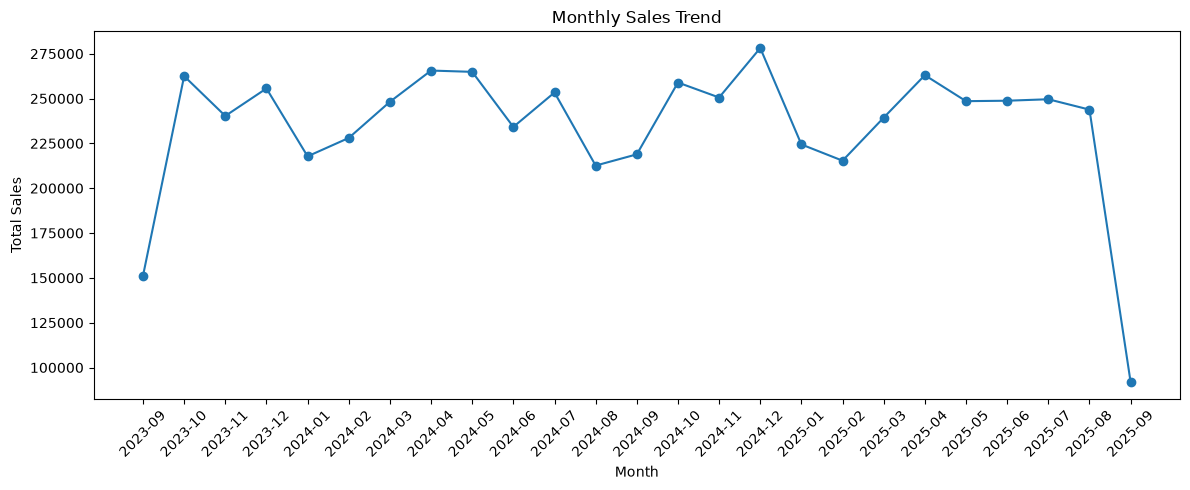

In [84]:
#月度销量趋势
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [85]:
monthly_orders=(df.groupby('year_month')['order_id'].nunique())
print(monthly_orders.idxmax(),monthly_orders.max())

2024-07 1501


In [86]:
monthly_aov=(monthly_sales/monthly_orders)
monthly_aov

year_month
2023-09    172.529224
2023-10    178.816580
2023-11    173.492354
2023-12    170.525037
2024-01    157.118391
2024-02    167.904256
2024-03    174.403570
2024-04    184.955891
2024-05    185.616840
2024-06    169.554946
2024-07    168.800400
2024-08    154.291147
2024-09    154.353949
2024-10    174.717456
2024-11    169.994600
2024-12    189.349346
2025-01    155.610409
2025-02    161.060726
2025-03    161.611621
2025-04    183.804354
2025-05    166.350375
2025-06    173.969427
2025-07    169.676071
2025-08    162.756008
2025-09    165.492198
dtype: float64

In [87]:
monthly_analysis=pd.DataFrame({'sales':monthly_sales,'orders':monthly_orders,'aov':monthly_aov})
monthly_analysis

,sales,orders,aov
year_month,,,
2023-09,151135.60,876,172.529224
2023-10,262502.74,1468,178.816580
2023-11,240286.91,1385,173.492354
2023-12,255617.03,1499,170.525037
2024-01,217766.09,1386,157.118391
2024-02,228013.98,1358,167.904256
2024-03,248176.28,1423,174.403570
2024-04,265596.66,1436,184.955891
2024-05,264875.23,1427,185.616840


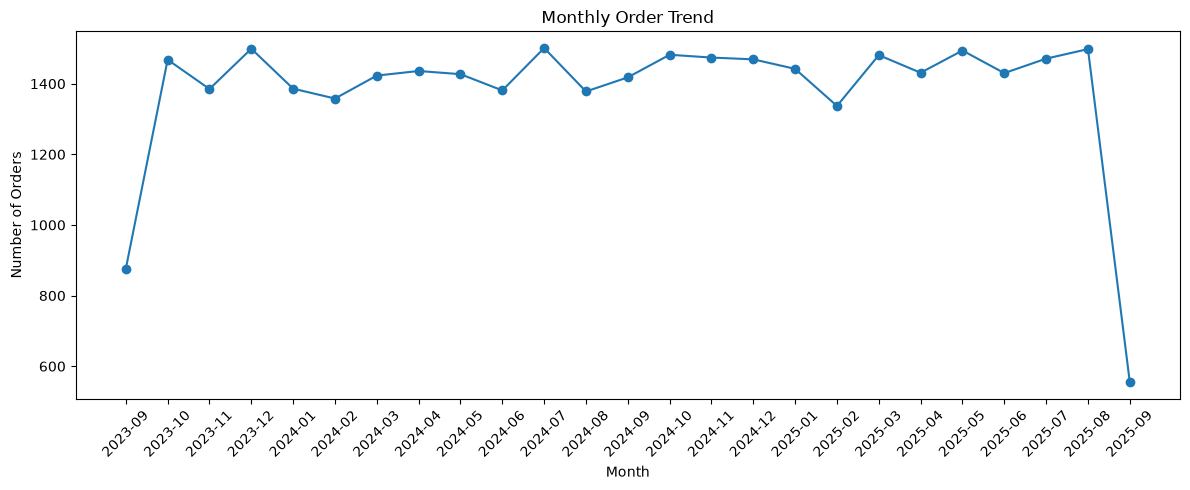

In [88]:
#月度订单趋势
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_orders.index,
    monthly_orders.values,
    marker="o"
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [89]:
monthly_analysis.sort_values('sales',ascending=False).head()

,sales,orders,aov
year_month,,,
2024-12,278154.19,1469,189.349346
2024-04,265596.66,1436,184.955891
2024-05,264875.23,1427,185.616840
2025-04,263024.03,1431,183.804354
2023-10,262502.74,1468,178.816580


In [90]:

# 月销售额
monthly_sales = (
    df.groupby("year_month")["total_amount"]
      .sum()
)

# 月订单量
monthly_orders = (
    df.groupby("year_month")["order_id"]
      .nunique()
)

# 月客单价
monthly_aov = monthly_sales / monthly_orders

# 汇总
monthly_analysis = pd.DataFrame({
    "sales": monthly_sales,
    "orders": monthly_orders,
    "aov": monthly_aov
})

print(monthly_analysis)

print(
    "\n销售额最高月份：",
    monthly_sales.idxmax(),
    round(monthly_sales.max(), 2)
)

print(
    "订单量最高月份：",
    monthly_orders.idxmax(),
    monthly_orders.max()
)

                sales  orders         aov
year_month                               
2023-09     151135.60     876  172.529224
2023-10     262502.74    1468  178.816580
2023-11     240286.91    1385  173.492354
2023-12     255617.03    1499  170.525037
2024-01     217766.09    1386  157.118391
2024-02     228013.98    1358  167.904256
2024-03     248176.28    1423  174.403570
2024-04     265596.66    1436  184.955891
2024-05     264875.23    1427  185.616840
2024-06     234155.38    1381  169.554946
2024-07     253369.40    1501  168.800400
2024-08     212613.20    1378  154.291147
2024-09     218873.90    1418  154.353949
2024-10     258931.27    1482  174.717456
2024-11     250572.04    1474  169.994600
2024-12     278154.19    1469  189.349346
2025-01     224390.21    1442  155.610409
2025-02     215338.19    1337  161.060726
2025-03     239346.81    1481  161.611621
2025-04     263024.03    1431  183.804354
2025-05     248527.46    1494  166.350375
2025-06     248776.28    1430  173

In [92]:
monthly_days = (
    df.groupby("year_month")["order_date"]
      .nunique()
)

monthly_days

year_month
2023-09    19
2023-10    31
2023-11    30
2023-12    31
2024-01    31
2024-02    29
2024-03    31
2024-04    30
2024-05    31
2024-06    30
2024-07    31
2024-08    31
2024-09    30
2024-10    31
2024-11    30
2024-12    31
2025-01    31
2025-02    28
2025-03    31
2025-04    30
2025-05    31
2025-06    30
2025-07    31
2025-08    31
2025-09    11
Name: order_date, dtype: int64

In [93]:
monthly_analysis_full=monthly_analysis.loc['2023-10':'2025-08']
monthly_analysis_full

,sales,orders,aov
year_month,,,
2023-10,262502.74,1468,178.816580
2023-11,240286.91,1385,173.492354
2023-12,255617.03,1499,170.525037
2024-01,217766.09,1386,157.118391
2024-02,228013.98,1358,167.904256
2024-03,248176.28,1423,174.403570
2024-04,265596.66,1436,184.955891
2024-05,264875.23,1427,185.616840
2024-06,234155.38,1381,169.554946


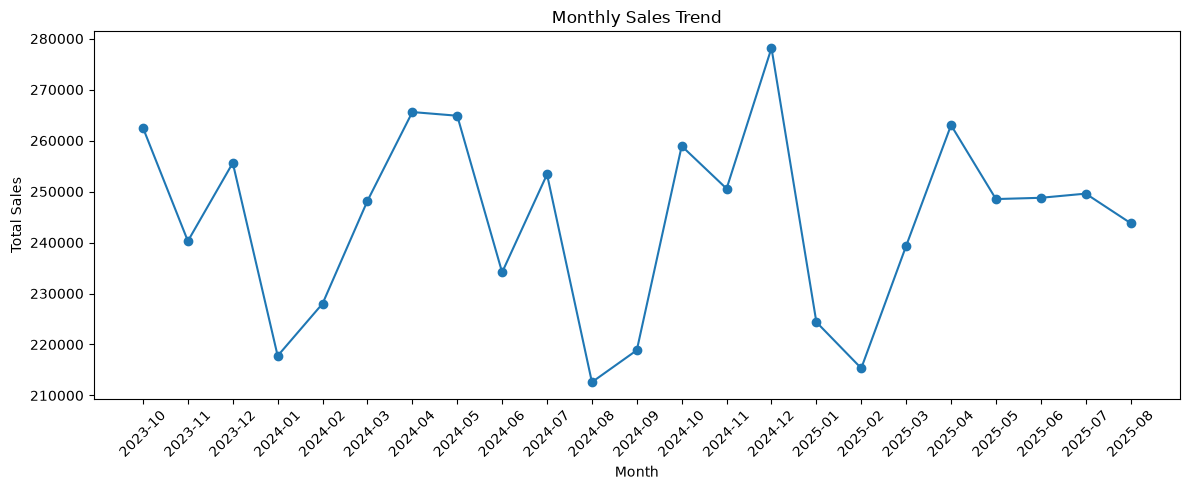

In [94]:
#月度销量趋势（去除不完整周期）
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_analysis_full.index,
    monthly_analysis_full["sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

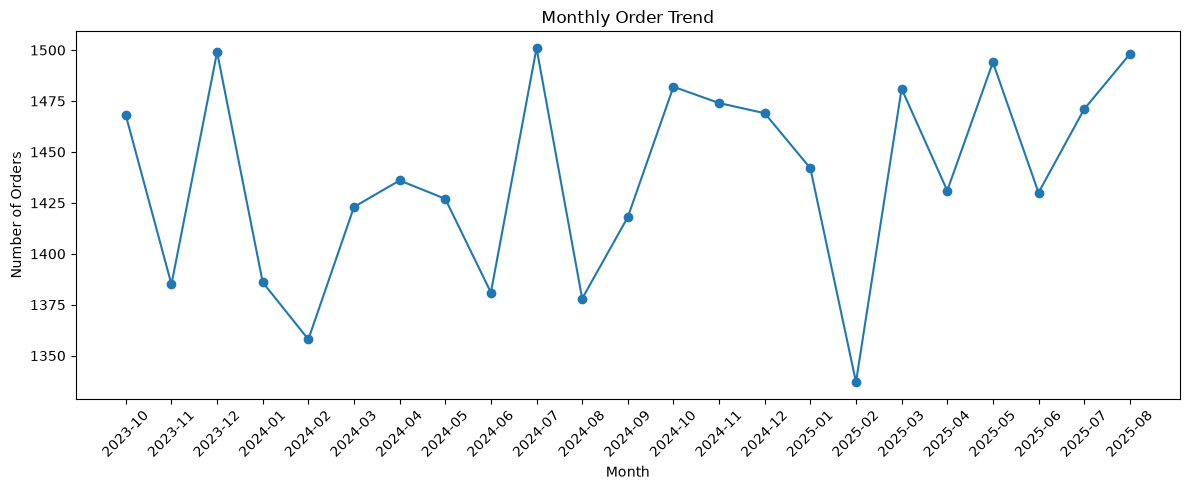

In [95]:
#月度订单趋势（去除不完整周期）
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_analysis_full.index,
    monthly_analysis_full["orders"],
    marker="o"
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [96]:
category_analysis=(df.groupby('category').agg(
    sales=('total_amount','sum'),
    orders=('order_id','count'),
    units=('quantity','sum'),
    profit=('profit_margin','sum')
)  )

category_analysis

,sales,orders,units,profit
category,,,,
Beauty,153019.38,4103,6122,49196.59
Electronics,3319206.50,6180,9343,344371.77
Fashion,471545.80,6254,9148,128814.65
Grocery,82000.51,4058,6031,-9187.96
Home,1077681.52,5487,8229,262633.70
Sports,629825.54,4171,6244,160521.41
Toys,132013.80,4247,6313,33669.25


In [97]:
#计算销售额占比
category_analysis['sales_share']=(category_analysis['sales']*100/gmv)
print(category_analysis)

                  sales  orders  units     profit  sales_share
category                                                      
Beauty        153019.38    4103   6122   49196.59     2.608896
Electronics  3319206.50    6180   9343  344371.77    56.590634
Fashion       471545.80    6254   9148  128814.65     8.039595
Grocery        82000.51    4058   6031   -9187.96     1.398063
Home         1077681.52    5487   8229  262633.70    18.373873
Sports        629825.54    4171   6244  160521.41    10.738177
Toys          132013.80    4247   6313   33669.25     2.250762


In [98]:
category_analysis['aov']=(category_analysis['sales']/category_analysis['orders'])
print(category_analysis)

                  sales  orders  units     profit  sales_share         aov
category                                                                  
Beauty        153019.38    4103   6122   49196.59     2.608896   37.294511
Electronics  3319206.50    6180   9343  344371.77    56.590634  537.088430
Fashion       471545.80    6254   9148  128814.65     8.039595   75.399073
Grocery        82000.51    4058   6031   -9187.96     1.398063   20.207124
Home         1077681.52    5487   8229  262633.70    18.373873  196.406328
Sports        629825.54    4171   6244  160521.41    10.738177  151.001088
Toys          132013.80    4247   6313   33669.25     2.250762   31.084012


In [99]:
category_analysis['profit_rate']=(category_analysis['profit']/category_analysis['sales'])
print(category_analysis)

                  sales  orders  units     profit  sales_share         aov  \
category                                                                     
Beauty        153019.38    4103   6122   49196.59     2.608896   37.294511   
Electronics  3319206.50    6180   9343  344371.77    56.590634  537.088430   
Fashion       471545.80    6254   9148  128814.65     8.039595   75.399073   
Grocery        82000.51    4058   6031   -9187.96     1.398063   20.207124   
Home         1077681.52    5487   8229  262633.70    18.373873  196.406328   
Sports        629825.54    4171   6244  160521.41    10.738177  151.001088   
Toys          132013.80    4247   6313   33669.25     2.250762   31.084012   

             profit_rate  
category                  
Beauty          0.321506  
Electronics     0.103751  
Fashion         0.273175  
Grocery        -0.112048  
Home            0.243703  
Sports          0.254866  
Toys            0.255043  


In [100]:
df['is_returned']=df['returned']=='Yes'
df[["returned", "is_returned"]].head()

,returned,is_returned
0,No,False
1,No,False
2,No,False
3,No,False
4,No,False


In [101]:
category_return_rate=(df.groupby('category')['is_returned'].mean())
category_analysis['return_rate']=(category_return_rate)

In [102]:
category_analysis['units_per_order']=(category_analysis['units']/category_analysis['orders'])

In [103]:
category_analysis=(category_analysis.sort_values('sales',ascending=False))
category_analysis

,sales,orders,units,profit,sales_share,aov,profit_rate,return_rate,units_per_order
category,,,,,,,,,
Electronics,3319206.50,6180,9343,344371.77,56.590634,537.088430,0.103751,0.072977,1.511812
Home,1077681.52,5487,8229,262633.70,18.373873,196.406328,0.243703,0.056497,1.499727
Sports,629825.54,4171,6244,160521.41,10.738177,151.001088,0.254866,0.049389,1.497003
Fashion,471545.80,6254,9148,128814.65,8.039595,75.399073,0.273175,0.082827,1.462744
Beauty,153019.38,4103,6122,49196.59,2.608896,37.294511,0.321506,0.037777,1.492079
Toys,132013.80,4247,6313,33669.25,2.250762,31.084012,0.255043,0.049447,1.486461
Grocery,82000.51,4058,6031,-9187.96,1.398063,20.207124,-0.112048,0.013061,1.486200


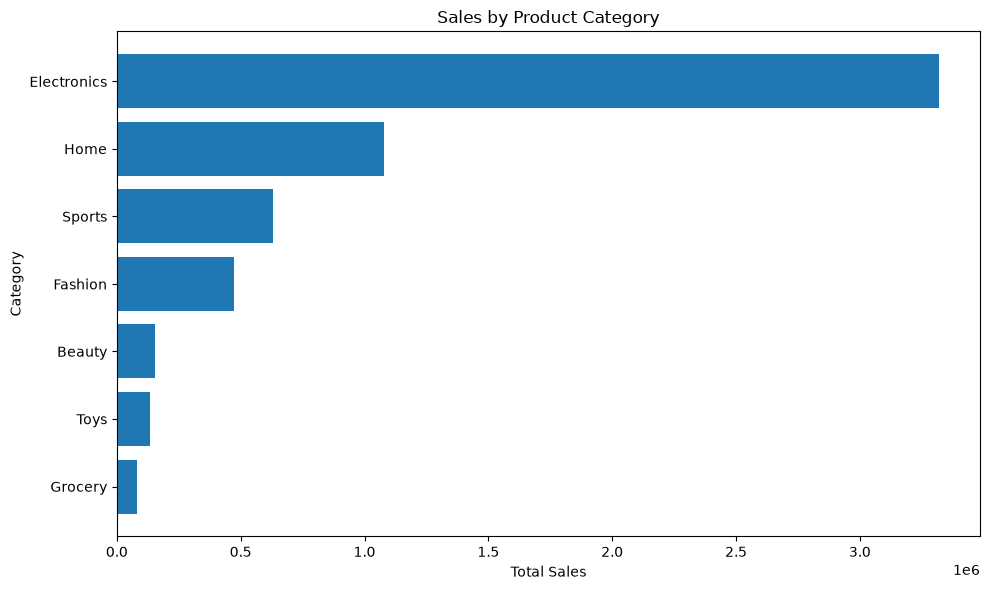

In [104]:
plt.figure(figsize=(10, 6))

plt.barh(
    category_analysis.index,
    category_analysis["sales"]
)

plt.title("Sales by Product Category")
plt.xlabel("Total Sales")
plt.ylabel("Category")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

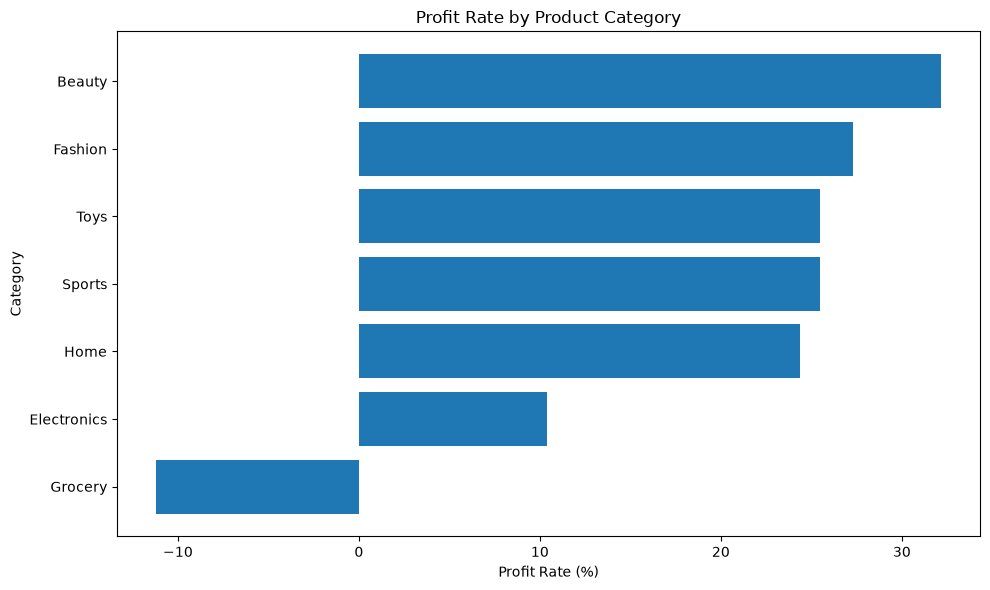

In [105]:
category_profit_rate=(category_analysis.sort_values('profit_rate',ascending=False))

plt.figure(figsize=(10, 6))

plt.barh(
    category_profit_rate.index,
    category_profit_rate["profit_rate"] * 100
)

plt.title("Profit Rate by Product Category")
plt.xlabel("Profit Rate (%)")
plt.ylabel("Category")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

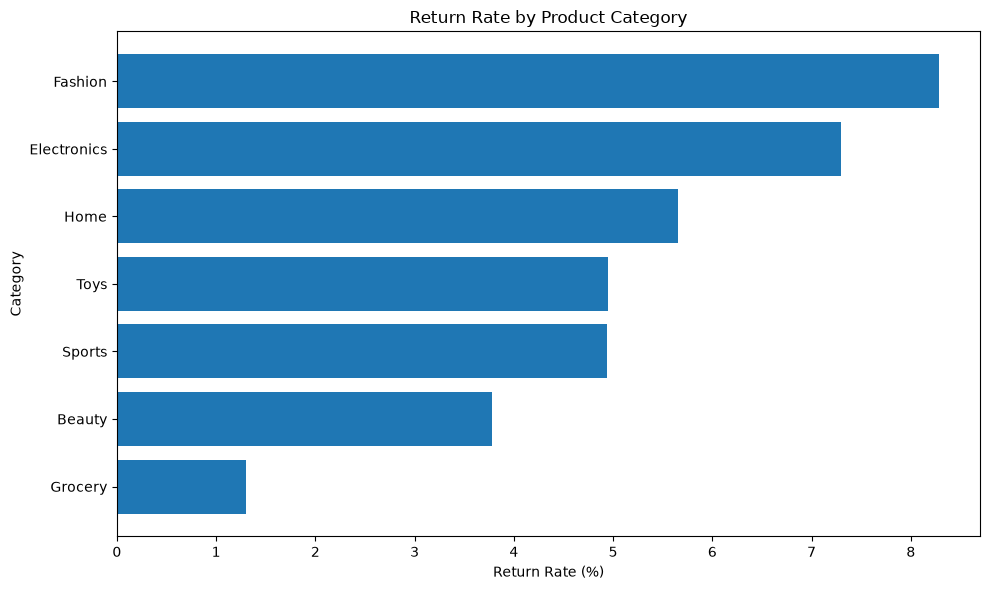

In [106]:
category_return=(category_analysis.sort_values('return_rate',ascending=False))

plt.figure(figsize=(10, 6))

plt.barh(
    category_return.index,
    category_return["return_rate"] * 100
)

plt.title("Return Rate by Product Category")
plt.xlabel("Return Rate (%)")
plt.ylabel("Category")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [107]:
#找出grocery亏损原因---比较各品类平均价格
category_price =(df.groupby('category')['price'].mean().sort_values(ascending=False))
category_price 

category
Electronics    374.418754
Home           137.484396
Sports         107.573388
Fashion         54.587242
Beauty          26.474460
Toys            22.165710
Grocery         14.264872
Name: price, dtype: float64

In [108]:
category_discount =(df.groupby('category')['discount'].mean().sort_values(ascending=False))
category_discount

category
Electronics    0.051068
Sports         0.049916
Beauty         0.049610
Fashion        0.048825
Grocery        0.048817
Home           0.048305
Toys           0.048199
Name: discount, dtype: float64

In [109]:
category_shipping =(df.groupby('category')['shipping_cost'].mean().sort_values(ascending=False))
category_shipping

category
Electronics    8.727034
Home           7.129098
Sports         6.815052
Fashion        5.792328
Beauty         4.792237
Toys           4.505846
Grocery        3.880734
Name: shipping_cost, dtype: float64

In [110]:
#邮费负担率
category_analysis['avg_shipping'] =(
    df.groupby('category')['shipping_cost'].mean())
category_analysis['shipping_burden']=(
    category_analysis['avg_shipping']/category_analysis['aov'])
category_analysis[
    ['sales', 'aov', 'avg_shipping',
     'shipping_burden', 'profit_rate']
].sort_values(
    'shipping_burden',
    ascending=False)

,sales,aov,avg_shipping,shipping_burden,profit_rate
category,,,,,
Grocery,82000.51,20.207124,3.880734,0.192048,-0.112048
Toys,132013.80,31.084012,4.505846,0.144957,0.255043
Beauty,153019.38,37.294511,4.792237,0.128497,0.321506
Fashion,471545.80,75.399073,5.792328,0.076822,0.273175
Sports,629825.54,151.001088,6.815052,0.045132,0.254866
Home,1077681.52,196.406328,7.129098,0.036298,0.243703
Electronics,3319206.50,537.088430,8.727034,0.016249,0.103751


In [114]:
category_analysis['profit_per_order']=(category_analysis['profit']/category_analysis['orders'])
category_analysis[
    ['sales', 'orders','aov', 'profit','profit_rate','profit_per_order']
].sort_values(
    'profit_per_order',
    ascending=False)

,sales,orders,aov,profit,profit_rate,profit_per_order
category,,,,,,
Electronics,3319206.50,6180,537.088430,344371.77,0.103751,55.723587
Home,1077681.52,5487,196.406328,262633.70,0.243703,47.864717
Sports,629825.54,4171,151.001088,160521.41,0.254866,38.485114
Fashion,471545.80,6254,75.399073,128814.65,0.273175,20.597162
Beauty,153019.38,4103,37.294511,49196.59,0.321506,11.990395
Toys,132013.80,4247,31.084012,33669.25,0.255043,7.927773
Grocery,82000.51,4058,20.207124,-9187.96,-0.112048,-2.264160


In [116]:
#Grocery到底有多少订单是在亏钱？
loss_order_rate=(df.assign(is_loss=df['profit_margin']<0)
    .groupby('category')['is_loss'].mean().sort_values(ascending=False))

In [117]:
grocery = df[df['category'] == 'Grocery']

grocery['profit_margin'].describe()

count    4058.000000
mean       -2.264160
std         1.654435
min        -6.200000
25%        -3.210000
50%        -2.410000
75%        -1.550000
max        26.470000
Name: profit_margin, dtype: float64

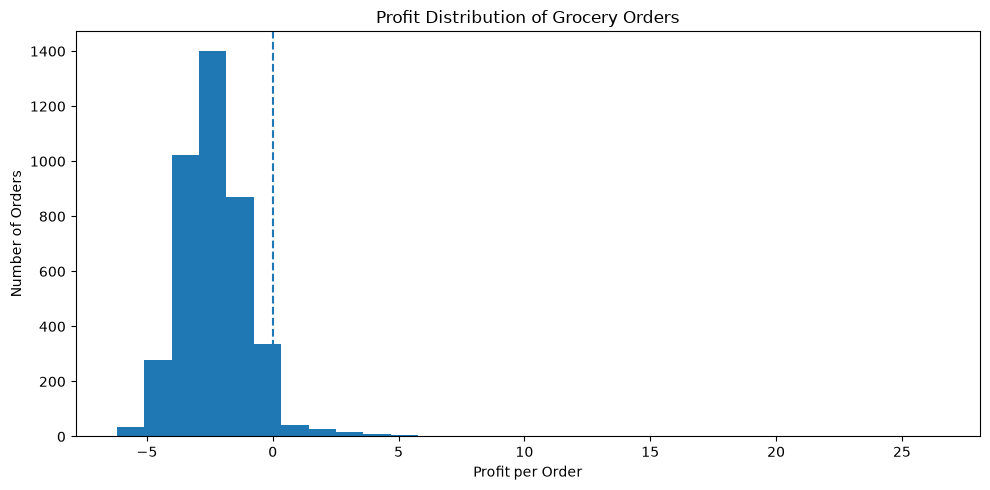

In [118]:
plt.figure(figsize=(10, 5))

plt.hist(
    grocery["profit_margin"],
    bins=30
)

plt.title("Profit Distribution of Grocery Orders")
plt.xlabel("Profit per Order")
plt.ylabel("Number of Orders")

plt.axvline(
    0,
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [119]:
grocery_diagnosis = pd.DataFrame({
    "avg_price":
        df.groupby("category")["price"].mean(),

    "avg_discount":
        df.groupby("category")["discount"].mean(),

    "avg_shipping":
        df.groupby("category")["shipping_cost"].mean(),

    "aov":
        category_analysis["aov"],

    "profit_per_order":
        category_analysis["profit_per_order"],

    "profit_rate":
        category_analysis["profit_rate"],

    "loss_order_rate":
        df.assign(
            is_loss=df["profit_margin"] < 0
        ).groupby("category")["is_loss"].mean()
})

grocery_diagnosis["shipping_burden"] = (
    grocery_diagnosis["avg_shipping"]
    / grocery_diagnosis["aov"]
)

grocery_diagnosis.sort_values(
    "profit_rate"
)

,avg_price,avg_discount,avg_shipping,aov,profit_per_order,profit_rate,loss_order_rate,shipping_burden
category,,,,,,,,
Grocery,14.264872,0.048817,3.880734,20.207124,-2.264160,-0.112048,0.954904,0.192048
Electronics,374.418754,0.051068,8.727034,537.088430,55.723587,0.103751,0.011327,0.016249
Home,137.484396,0.048305,7.129098,196.406328,47.864717,0.243703,0.031347,0.036298
Sports,107.573388,0.049916,6.815052,151.001088,38.485114,0.254866,0.025174,0.045132
Toys,22.165710,0.048199,4.505846,31.084012,7.927773,0.255043,0.210266,0.144957
Fashion,54.587242,0.048825,5.792328,75.399073,20.597162,0.273175,0.081708,0.076822
Beauty,26.474460,0.049610,4.792237,37.294511,11.990395,0.321506,0.116500,0.128497


In [120]:
#区域分析
df['region'].value_counts()

region
South      7584
North      7572
East       6904
West       6808
Central    5632
Name: count, dtype: int64

In [121]:
df['region'].nunique()

5

In [122]:
region_analysis = (
    df.groupby("region")
      .agg(
          sales=("total_amount", "sum"),
          orders=("order_id", "nunique"),
          customers=("customer_id", "nunique"),
          units=("quantity", "sum"),
          profit=("profit_margin", "sum"),
          avg_delivery_days=("delivery_time_days", "mean")
      )
)

region_analysis

,sales,orders,customers,units,profit,avg_delivery_days
region,,,,,,
Central,940503.38,5632,4047,8392,158023.69,4.006392
East,1176334.75,6904,4568,10375,195035.24,5.988847
North,1264008.35,7572,4846,11310,208493.58,3.984680
South,1298096.07,7584,4925,11294,211081.17,5.005406
West,1186350.50,6808,4543,10059,197385.73,5.000881


In [124]:
region_analysis["sales_share"] = (
    region_analysis["sales"] / gmv
)

region_analysis["aov"] = (
    region_analysis["sales"]
    / region_analysis["orders"]
)

region_analysis["profit_rate"] = (
    region_analysis["profit"]
    / region_analysis["sales"]
)

region_analysis["units_per_order"] = (
    region_analysis["units"]
    / region_analysis["orders"]
)

region_analysis["return_rate"] = (
    df.groupby("region")["is_returned"]
      .mean()
)

region_analysis = (
    region_analysis
    .sort_values("sales", ascending=False)
)

region_analysis

,sales,orders,customers,units,profit,avg_delivery_days,sales_share,aov,profit_rate,units_per_order,return_rate
region,,,,,,,,,,,
South,1298096.07,7584,4925,11294,211081.17,5.005406,0.221318,171.162456,0.162608,1.489188,0.056830
North,1264008.35,7572,4846,11310,208493.58,3.984680,0.215506,166.931900,0.164946,1.493661,0.053619
West,1186350.50,6808,4543,10059,197385.73,5.000881,0.202266,174.258299,0.166381,1.477526,0.054495
East,1176334.75,6904,4568,10375,195035.24,5.988847,0.200559,170.384523,0.165799,1.502752,0.059096
Central,940503.38,5632,4047,8392,158023.69,4.006392,0.160351,166.992788,0.168020,1.490057,0.050959


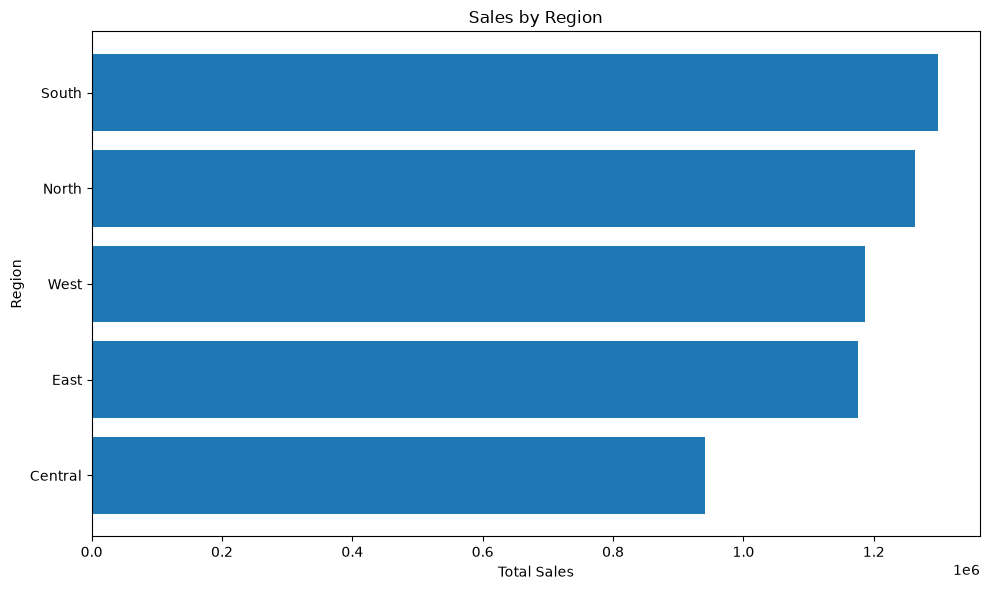

In [125]:
plt.figure(figsize=(10, 6))

plt.barh(
    region_analysis.index,
    region_analysis["sales"]
)

plt.title("Sales by Region")
plt.xlabel("Total Sales")
plt.ylabel("Region")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [126]:
region_profit = (
    region_analysis
    .sort_values("profit_rate", ascending=False)
)

region_profit[
    ["sales", "profit", "profit_rate", "aov"]
]

,sales,profit,profit_rate,aov
region,,,,
Central,940503.38,158023.69,0.168020,166.992788
West,1186350.50,197385.73,0.166381,174.258299
East,1176334.75,195035.24,0.165799,170.384523
North,1264008.35,208493.58,0.164946,166.931900
South,1298096.07,211081.17,0.162608,171.162456


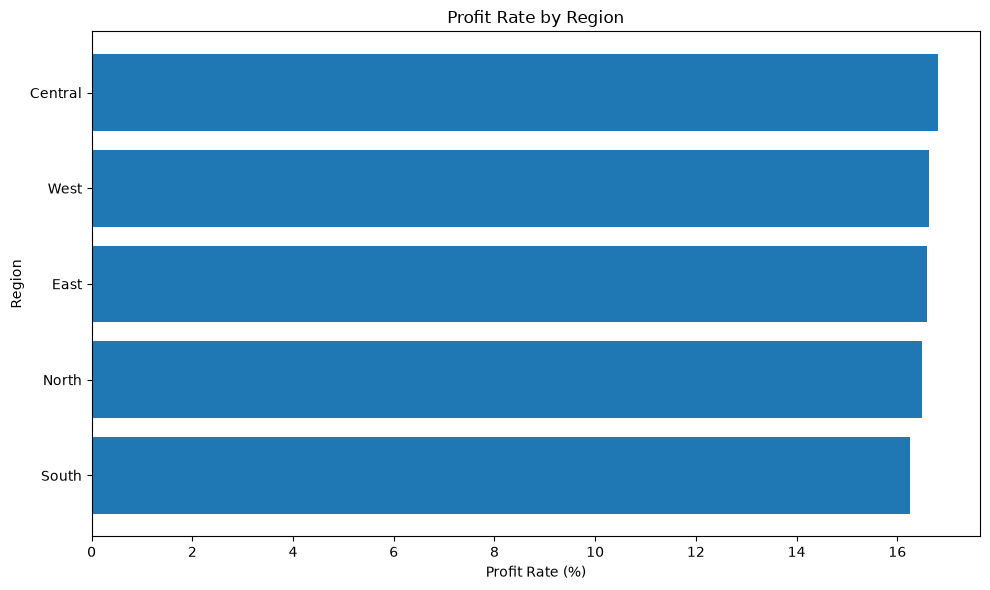

In [127]:
plt.figure(figsize=(10, 6))

plt.barh(
    region_profit.index,
    region_profit["profit_rate"] * 100
)

plt.title("Profit Rate by Region")
plt.xlabel("Profit Rate (%)")
plt.ylabel("Region")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [128]:
region_return = (
    region_analysis
    .sort_values("return_rate", ascending=False)
)

region_return[
    ["orders", "return_rate", "avg_delivery_days"]
]

,orders,return_rate,avg_delivery_days
region,,,
East,6904,0.059096,5.988847
South,7584,0.056830,5.005406
West,6808,0.054495,5.000881
North,7572,0.053619,3.984680
Central,5632,0.050959,4.006392


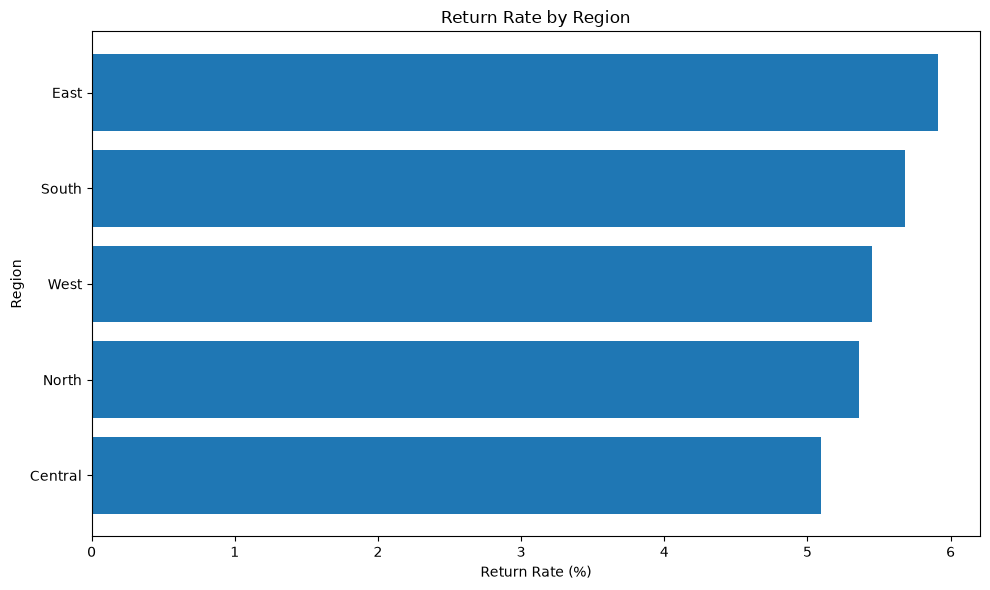

In [129]:
plt.figure(figsize=(10, 6))

plt.barh(
    region_return.index,
    region_return["return_rate"] * 100
)

plt.title("Return Rate by Region")
plt.xlabel("Return Rate (%)")
plt.ylabel("Region")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [130]:
region_delivery = (
    region_analysis
    .sort_values(
        "avg_delivery_days",
        ascending=False
    )
)

region_delivery[
    ["avg_delivery_days", "return_rate", "sales"]
]

,avg_delivery_days,return_rate,sales
region,,,
East,5.988847,0.059096,1176334.75
South,5.005406,0.056830,1298096.07
West,5.000881,0.054495,1186350.50
Central,4.006392,0.050959,940503.38
North,3.984680,0.053619,1264008.35


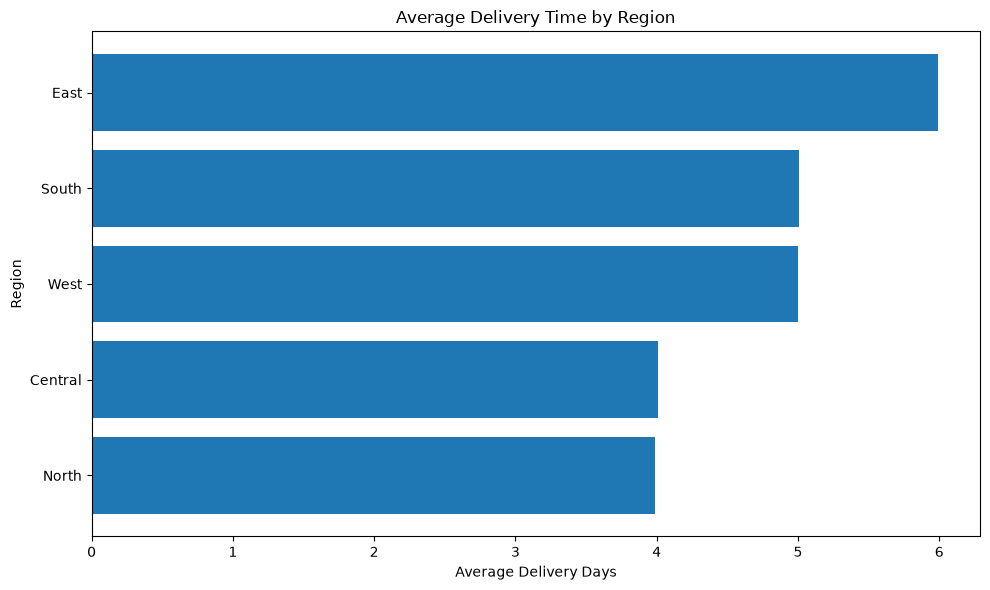

In [131]:
plt.figure(figsize=(10, 6))

plt.barh(
    region_delivery.index,
    region_delivery["avg_delivery_days"]
)

plt.title("Average Delivery Time by Region")
plt.xlabel("Average Delivery Days")
plt.ylabel("Region")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [132]:
region_diagnosis = region_analysis[
    [
        "sales",
        "orders",
        "aov",
        "profit_rate",
        "return_rate",
        "avg_delivery_days"
    ]
].copy()

region_diagnosis.round({
    "sales": 2,
    "aov": 2,
    "profit_rate": 4,
    "return_rate": 4,
    "avg_delivery_days": 2
})

,sales,orders,aov,profit_rate,return_rate,avg_delivery_days
region,,,,,,
South,1298096.07,7584,171.16,0.1626,0.0568,5.01
North,1264008.35,7572,166.93,0.1649,0.0536,3.98
West,1186350.50,6808,174.26,0.1664,0.0545,5.00
East,1176334.75,6904,170.38,0.1658,0.0591,5.99
Central,940503.38,5632,166.99,0.1680,0.0510,4.01


In [133]:
delivery_return = (
    df.groupby("delivery_time_days")
      .agg(
          orders=("order_id", "nunique"),
          return_rate=("is_returned", "mean")
      )
)

delivery_return["return_rate_pct"] = (
    delivery_return["return_rate"] * 100
)

delivery_return

,orders,return_rate,return_rate_pct
delivery_time_days,,,
3,4907,0.052374,5.237416
4,10094,0.055181,5.518130
5,10296,0.055361,5.536131
6,5961,0.057205,5.720517
7,2400,0.052917,5.291667
8,663,0.057315,5.731523
9,152,0.078947,7.894737
10,25,0.040000,4.000000
12,1,0.000000,0.000000


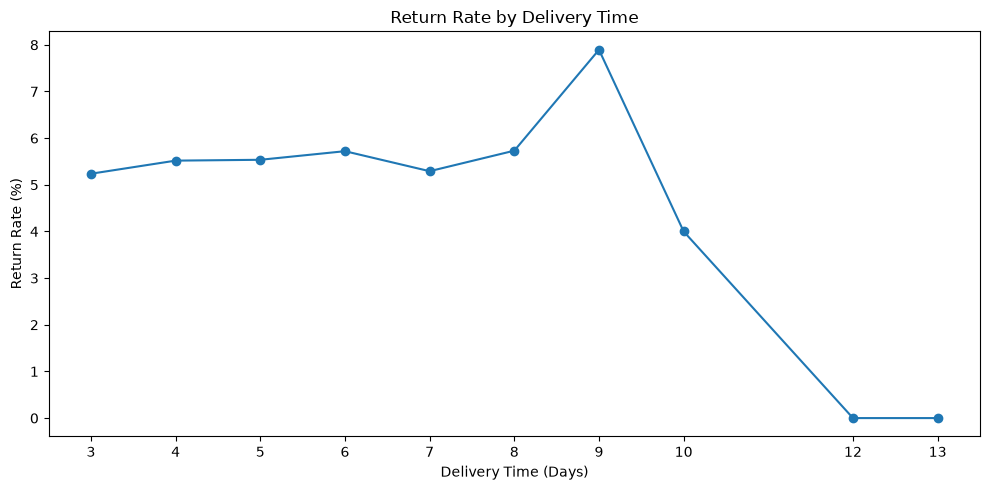

In [134]:
plt.figure(figsize=(10, 5))

plt.plot(
    delivery_return.index,
    delivery_return["return_rate_pct"],
    marker="o"
)

plt.title("Return Rate by Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Return Rate (%)")

plt.xticks(delivery_return.index)

plt.tight_layout()
plt.show()

In [135]:

def delivery_group(days):
    if days <= 4:
        return "Fast"
    elif days <= 6:
        return "Normal"
    else:
        return "Slow"

df["delivery_group"] = (
    df["delivery_time_days"]
      .apply(delivery_group)
)

delivery_group_analysis = (
    df.groupby("delivery_group")
      .agg(
          orders=("order_id", "nunique"),
          return_rate=("is_returned", "mean")
      )
)

delivery_group_analysis["return_rate_pct"] = (
    delivery_group_analysis["return_rate"] * 100
)

delivery_group_analysis

,orders,return_rate,return_rate_pct
delivery_group,,,
Fast,15001,0.054263,5.426305
Normal,16257,0.056037,5.603740
Slow,3242,0.054904,5.490438


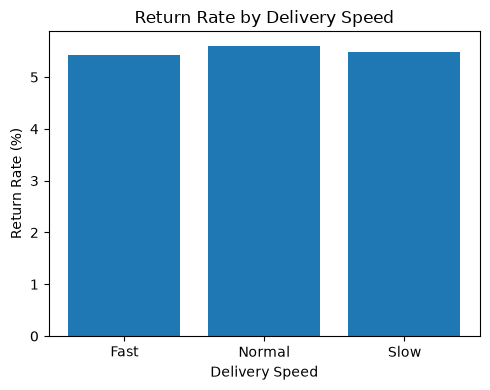

In [138]:
delivery_group_analysis = (
    delivery_group_analysis
    .reindex(["Fast", "Normal", "Slow"])
)

plt.figure(figsize=(5, 4))

plt.bar(
    delivery_group_analysis.index,
    delivery_group_analysis["return_rate_pct"]
)

plt.title("Return Rate by Delivery Speed")
plt.xlabel("Delivery Speed")
plt.ylabel("Return Rate (%)")

plt.tight_layout()
plt.show()

In [139]:
print("客户数：", df["customer_id"].nunique())
print("订单数：", df["order_id"].nunique())

print(
    "平均每位客户订单数：",
    df["order_id"].nunique() / df["customer_id"].nunique()
)

客户数： 7903
订单数： 34500
平均每位客户订单数： 4.3654308490446665


In [140]:
customer_order_count = (
    df.groupby("customer_id")["order_id"]
      .nunique()
)

customer_order_count.describe()

count    7903.000000
mean        4.365431
std         2.048718
min         1.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        13.000000
Name: order_id, dtype: float64

In [141]:
df["customer_age"].describe()

count    34500.000000
mean        43.474377
std         14.980682
min         18.000000
25%         31.000000
50%         43.000000
75%         56.000000
max         69.000000
Name: customer_age, dtype: float64

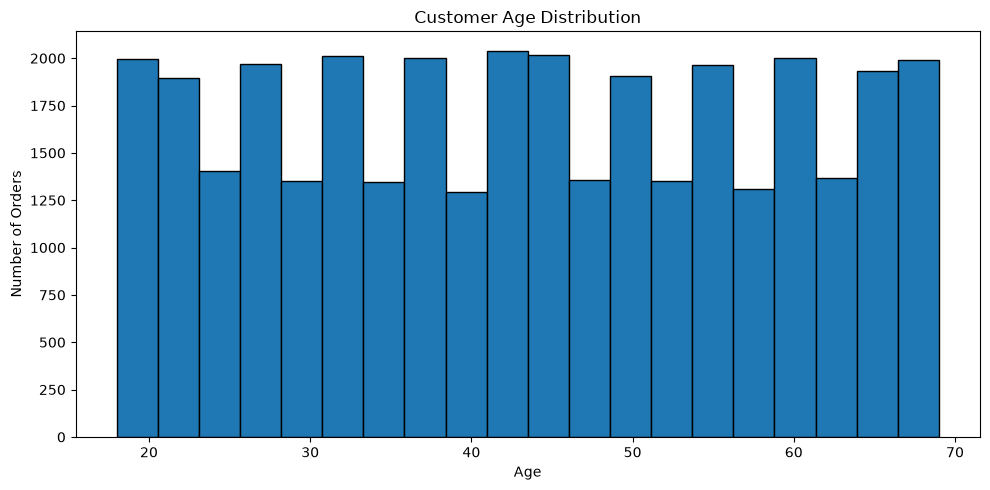

In [142]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["customer_age"],
    bins=20,
    edgecolor="black"
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [143]:
#去掉重复下单的客户以确定真正的客户年龄分布
customer_profile = (
    df.sort_values("order_date")
      .drop_duplicates(
          subset="customer_id",
          keep="last"
      )
      [["customer_id", "customer_age", "customer_gender"]]
)

customer_profile.head()

,customer_id,customer_age,customer_gender
2390,C16072,64,Male
6311,C17178,37,Female
8611,C11450,48,Female
3774,C13586,41,Female
27059,C15665,53,Female


In [144]:
customer_profile.shape

(7903, 3)

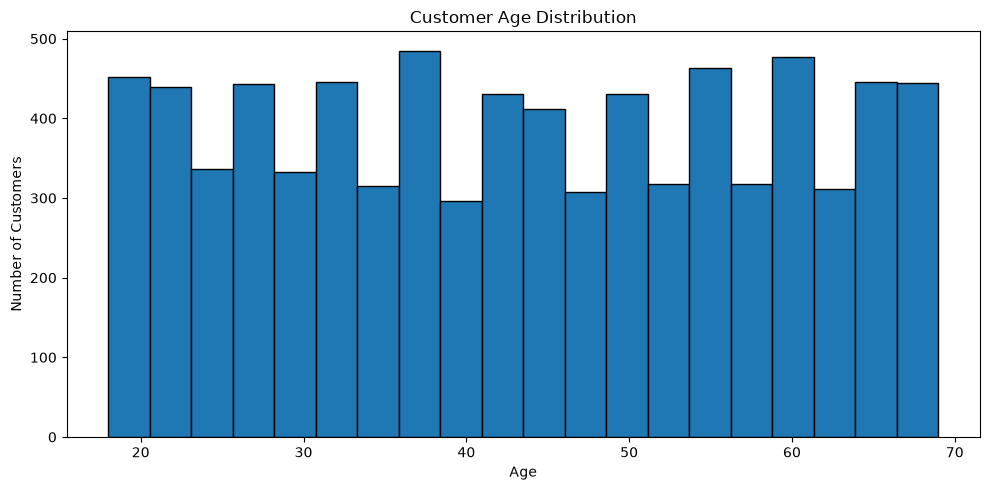

In [146]:
plt.figure(figsize=(10, 5))

plt.hist(
    customer_profile["customer_age"],
    bins=20,
    edgecolor="black"
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [147]:
age_bins = [17, 25, 35, 45, 55, 70]

age_labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-70"
]

df["age_group"] = pd.cut(
    df["customer_age"],
    bins=age_bins,
    labels=age_labels
)

In [149]:
age_analysis = (
    df.groupby(
        "age_group",
        observed=True
    )
    .agg(
        sales=("total_amount", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_id", "nunique"),
        profit=("profit_margin", "sum")
    )
)

age_analysis["sales_share"] = (
    age_analysis["sales"]
    / age_analysis["sales"].sum()
)

age_analysis["aov"] = (
    age_analysis["sales"]
    / age_analysis["orders"]
)

age_analysis["profit_rate"] = (
    age_analysis["profit"]
    / age_analysis["sales"]
)

age_analysis

,sales,orders,customers,profit,sales_share,aov,profit_rate
age_group,,,,,,,
18-25,947394.88,5298,3846,155856.33,0.161526,178.821231,0.164510
26-35,1147506.79,6678,4532,187577.04,0.195644,171.833901,0.163465
36-45,1123566.90,6678,4527,187628.72,0.191562,168.249012,0.166994
46-55,1131917.14,6609,4469,185659.10,0.192986,171.269048,0.164022
56-70,1514907.34,9237,5527,253298.22,0.258283,164.004259,0.167204


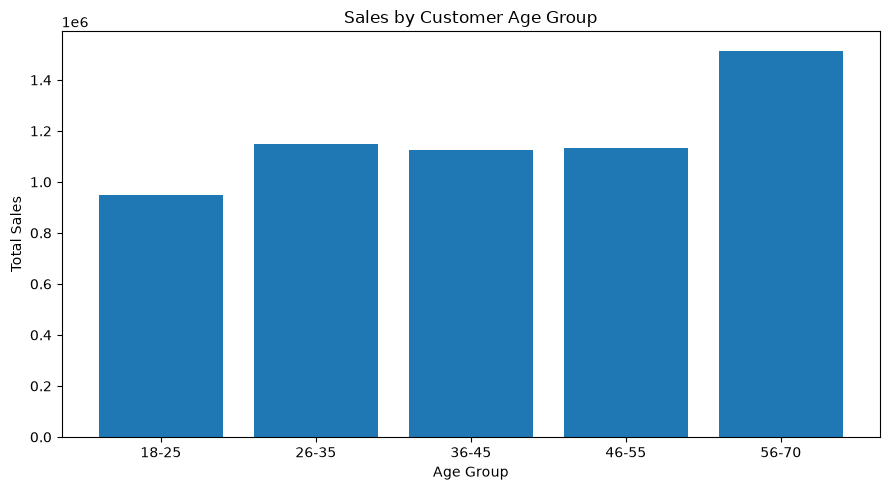

In [150]:
plt.figure(figsize=(9, 5))

plt.bar(
    age_analysis.index.astype(str),
    age_analysis["sales"]
)

plt.title("Sales by Customer Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

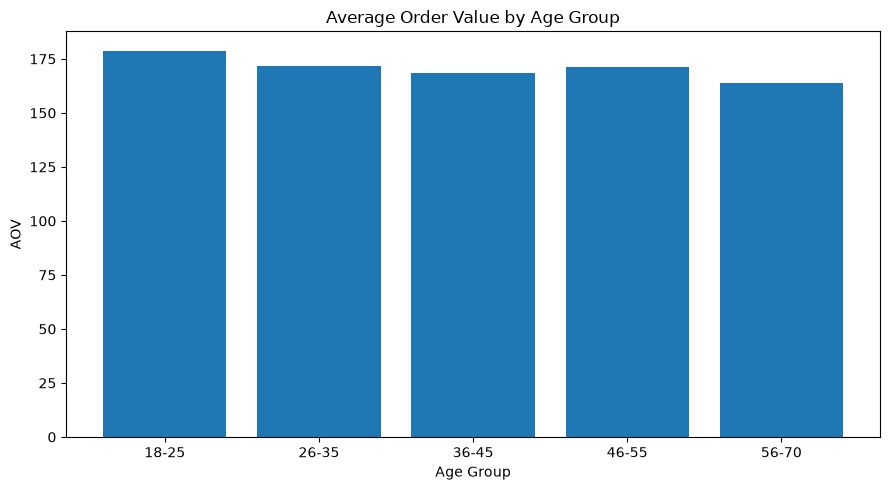

In [151]:
plt.figure(figsize=(9, 5))

plt.bar(
    age_analysis.index.astype(str),
    age_analysis["aov"]
)

plt.title("Average Order Value by Age Group")
plt.xlabel("Age Group")
plt.ylabel("AOV")

plt.tight_layout()
plt.show()

In [152]:
df["customer_gender"].value_counts()
gender_analysis = (
    df.groupby("customer_gender")
      .agg(
          sales=("total_amount", "sum"),
          orders=("order_id", "nunique"),
          customers=("customer_id", "nunique"),
          profit=("profit_margin", "sum")
      )
)

gender_analysis["aov"] = (
    gender_analysis["sales"]
    / gender_analysis["orders"]
)

gender_analysis["profit_rate"] = (
    gender_analysis["profit"]
    / gender_analysis["sales"]
)

gender_analysis["sales_share"] = (
    gender_analysis["sales"]
    / gender_analysis["sales"].sum()
)

gender_analysis

,sales,orders,customers,profit,aov,profit_rate,sales_share
customer_gender,,,,,,,
Female,2853296.96,16818,7026,470965.95,169.657329,0.165060,0.486471
Male,2793055.33,16310,6981,463036.50,171.248028,0.165781,0.476200
Other,218940.76,1372,1276,36016.96,159.577813,0.164506,0.037328


In [153]:
print("客户数：", df["customer_id"].nunique())
print("订单数：", df["order_id"].nunique())

customer_order_count.describe()

客户数： 7903
订单数： 34500


count    7903.000000
mean        4.365431
std         2.048718
min         1.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        13.000000
Name: order_id, dtype: float64

In [154]:
age_analysis.round(2)

,sales,orders,customers,profit,sales_share,aov,profit_rate
age_group,,,,,,,
18-25,947394.88,5298,3846,155856.33,0.16,178.82,0.16
26-35,1147506.79,6678,4532,187577.04,0.20,171.83,0.16
36-45,1123566.90,6678,4527,187628.72,0.19,168.25,0.17
46-55,1131917.14,6609,4469,185659.10,0.19,171.27,0.16
56-70,1514907.34,9237,5527,253298.22,0.26,164.00,0.17


In [155]:
gender_analysis.round(2)

,sales,orders,customers,profit,aov,profit_rate,sales_share
customer_gender,,,,,,,
Female,2853296.96,16818,7026,470965.95,169.66,0.17,0.49
Male,2793055.33,16310,6981,463036.50,171.25,0.17,0.48
Other,218940.76,1372,1276,36016.96,159.58,0.16,0.04


In [156]:
customer_analysis = (
    df.groupby("customer_id")
      .agg(
          orders=("order_id", "nunique"),
          total_spend=("total_amount", "sum"),
          total_profit=("profit_margin", "sum"),
          first_purchase=("order_date", "min"),
          last_purchase=("order_date", "max")
      )
)

customer_analysis.head()

,orders,total_spend,total_profit,first_purchase,last_purchase
customer_id,,,,,
C10000,2,210.58,19.71,2024-08-17,2025-09-07
C10001,5,3246.02,493.90,2024-01-20,2025-03-02
C10002,5,216.85,31.39,2023-11-15,2024-08-07
C10003,3,154.30,26.28,2024-06-19,2025-07-02
C10004,3,716.99,82.70,2023-11-28,2024-01-21


In [157]:
customer_analysis["aov"] = (
    customer_analysis["total_spend"]
    / customer_analysis["orders"]
)

customer_analysis["profit_rate"] = (
    customer_analysis["total_profit"]
    / customer_analysis["total_spend"]
)

customer_analysis.head()

,orders,total_spend,total_profit,first_purchase,last_purchase,aov,profit_rate
customer_id,,,,,,,
C10000,2,210.58,19.71,2024-08-17,2025-09-07,105.290000,0.093599
C10001,5,3246.02,493.90,2024-01-20,2025-03-02,649.204000,0.152156
C10002,5,216.85,31.39,2023-11-15,2024-08-07,43.370000,0.144754
C10003,3,154.30,26.28,2024-06-19,2025-07-02,51.433333,0.170318
C10004,3,716.99,82.70,2023-11-28,2024-01-21,238.996667,0.115343


In [158]:
customer_analysis["orders"].value_counts().sort_index()
frequency_analysis = (
    customer_analysis["orders"]
    .value_counts()
    .sort_index()
    .rename_axis("purchase_frequency")
    .reset_index(name="customers")
)

frequency_analysis

,purchase_frequency,customers
0,1,475
1,2,1033
2,3,1452
3,4,1488
4,5,1281
5,6,995
6,7,599
7,8,299
8,9,167
9,10,76


In [159]:
frequency_analysis["customer_share"] = (
    frequency_analysis["customers"]
    / frequency_analysis["customers"].sum()
)

frequency_analysis

,purchase_frequency,customers,customer_share
0,1,475,0.060104
1,2,1033,0.130710
2,3,1452,0.183728
3,4,1488,0.188283
4,5,1281,0.162090
5,6,995,0.125902
6,7,599,0.075794
7,8,299,0.037834
8,9,167,0.021131
9,10,76,0.009617


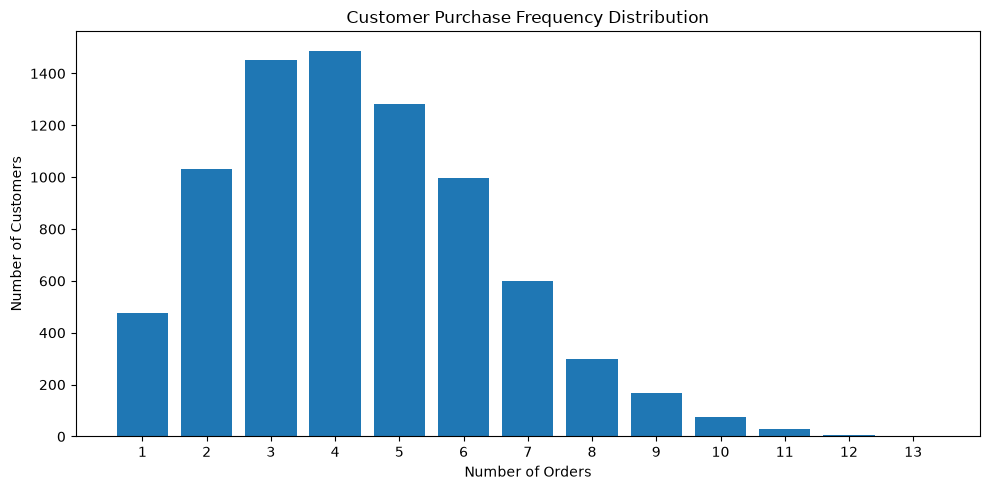

In [160]:
plt.figure(figsize=(10, 5))

plt.bar(
    frequency_analysis["purchase_frequency"],
    frequency_analysis["customers"]
)

plt.title("Customer Purchase Frequency Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.xticks(frequency_analysis["purchase_frequency"])

plt.tight_layout()
plt.show()

In [161]:
customer_analysis["is_repeat_customer"] = (
    customer_analysis["orders"] >= 2
)

repeat_rate = (
    customer_analysis["is_repeat_customer"].mean()
)

print(f"复购率：{repeat_rate:.2%}")

复购率：93.99%


In [163]:
repeat_analysis = (
    customer_analysis
    .groupby("is_repeat_customer")
    .agg(
        customers=("orders", "size"),
        orders=("orders", "sum"),
        sales=("total_spend", "sum"),
        profit=("total_profit", "sum")
    )
)

repeat_analysis.index = (
    repeat_analysis.index
    .map({
        False: "One-time",
        True: "Repeat"
    })
)

repeat_analysis["customer_share"] = (
    repeat_analysis["customers"]
    / repeat_analysis["customers"].sum()
)

repeat_analysis["sales_share"] = (
    repeat_analysis["sales"]
    / repeat_analysis["sales"].sum()
)

repeat_analysis["sales_per_customer"] = (
    repeat_analysis["sales"]
    / repeat_analysis["customers"]
)

repeat_analysis.round(2)

repeat_analysis

,customers,orders,sales,profit,customer_share,sales_share,sales_per_customer
is_repeat_customer,,,,,,,
One-time,475,475,84117.69,13933.70,0.060104,0.014342,177.089874
Repeat,7428,34025,5781175.36,956085.71,0.939896,0.985658,778.295013


In [165]:
customer_value = (
    customer_analysis
    .sort_values(
        "total_spend",
        ascending=False
    )
    .copy()
)

customer_value[
    ["orders", "total_spend", "aov"]
].head(10)

,orders,total_spend,aov
customer_id,,,
C16655,10,13885.10,1388.510000
C13565,5,11984.28,2396.856000
C15379,3,11375.58,3791.860000
C17116,5,7424.34,1484.868000
C15644,7,7244.07,1034.867143
C10975,10,7209.12,720.912000
C16382,10,6973.06,697.306000
C13767,6,6546.60,1091.100000
C15254,5,6509.95,1301.990000


In [166]:
top_20_n = int(
    len(customer_value) * 0.2
)

top_20_n

1580

In [167]:
top_20_sales = (
    customer_value
    .head(top_20_n)["total_spend"]
    .sum()
)

total_customer_sales = (
    customer_value["total_spend"].sum()
)

top_20_sales_share = (
    top_20_sales
    / total_customer_sales
)

print(
    f"Top 20%客户销售贡献占比："
    f"{top_20_sales_share:.2%}"
)

Top 20%客户销售贡献占比：53.95%


In [169]:
df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce"
)

In [170]:
df["order_date"].dtype

dtype('<M8[ns]')

In [171]:
df["order_date"].isna().sum()

np.int64(0)

In [172]:
print("最早订单日期：", df["order_date"].min())
print("最晚订单日期：", df["order_date"].max())

最早订单日期： 2023-09-12 00:00:00
最晚订单日期： 2025-09-11 00:00:00


In [173]:
analysis_date = (
    df["order_date"].max()
    + pd.Timedelta(days=1)
)

analysis_date

C:\Users\GUAN LI\AppData\Local\Temp\ipykernel_33600\2482570039.py:3: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  + pd.Timedelta(days=1)


Timestamp('2025-09-12 00:00:00')

In [174]:
customer_analysis = (
    df.groupby("customer_id")
      .agg(
          orders=("order_id", "nunique"),
          total_spend=("total_amount", "sum"),
          total_profit=("profit_margin", "sum"),
          first_purchase=("order_date", "min"),
          last_purchase=("order_date", "max")
      )
)

customer_analysis["aov"] = (
    customer_analysis["total_spend"]
    / customer_analysis["orders"]
)

customer_analysis["profit_rate"] = (
    customer_analysis["total_profit"]
    / customer_analysis["total_spend"]
)

In [175]:
customer_analysis["recency"] = (
    analysis_date
    - customer_analysis["last_purchase"]
).dt.days

In [176]:
customer_analysis[
    ["recency", "orders", "total_spend"]
].describe()

,recency,orders,total_spend
count,7903.000000,7903.000000,7903.000000
mean,159.008478,4.365431,742.160325
std,147.064936,2.048718,827.178631
min,1.000000,1.000000,1.240000
25%,47.000000,3.000000,215.885000
50%,115.000000,4.000000,494.450000
75%,226.000000,6.000000,972.460000
max,729.000000,13.000000,13885.100000


In [181]:
customer_analysis["R_score"] = pd.qcut(
    customer_analysis["recency"],
    q=3,
    labels=[3, 2, 1]
)

def frequency_score(x):
    if x <= 3:
        return 1
    elif x <= 5:
        return 2
    else:
        return 3

customer_analysis["F_score"] = (
    customer_analysis["orders"]
    .apply(frequency_score)
)

customer_analysis["M_score"] = pd.qcut(
    customer_analysis["total_spend"],
    q=3,
    labels=[1, 2, 3]
)

customer_analysis[
    [
        "recency",
        "orders",
        "total_spend",
        "R_score",
        "F_score",
        "M_score"
    ]
].head(10)

,recency,orders,total_spend,R_score,F_score,M_score
customer_id,,,,,,
C10000,5,2,210.58,3,1,1
C10001,194,5,3246.02,1,2,3
C10002,401,5,216.85,1,2,1
C10003,72,3,154.30,2,1,1
C10004,600,3,716.99,1,1,2
C10005,210,3,216.26,1,1,1
C10006,201,2,355.74,1,1,2
C10007,70,6,734.63,2,3,2
C10008,34,2,276.66,3,1,1


In [183]:
def customer_segment(row):

    if (
        row["R_score"] == 3
        and row["F_score"] == 3
        and row["M_score"] == 3
    ):
        return "Core"

    elif (
        row["R_score"] == 1
        and row["F_score"] >= 2
        and row["M_score"] >= 2
    ):
        return "At Risk"

    elif (
        row["R_score"] == 3
        and row["F_score"] <= 2
    ):
        return "Potential"

    else:
        return "Regular"

customer_analysis["segment"] = (
    customer_analysis.apply(
        customer_segment,
        axis=1
    )
)

In [185]:
segment_analysis = (
    customer_analysis
    .groupby("segment")
    .agg(
        customers=("orders", "size"),
        sales=("total_spend", "sum"),
        avg_orders=("orders", "mean"),
        avg_spend=("total_spend", "mean"),
        avg_recency=("recency", "mean")
    )
)

segment_analysis["customer_share"] = (
    segment_analysis["customers"]
    / segment_analysis["customers"].sum()
)

segment_analysis["sales_share"] = (
    segment_analysis["sales"]
    / segment_analysis["sales"].sum()
)

segment_analysis.round(2)

,customers,sales,avg_orders,avg_spend,avg_recency,customer_share,sales_share
segment,,,,,,,
At Risk,842,852132.76,5.17,1012.03,271.71,0.11,0.15
Core,684,1127032.62,7.36,1647.71,29.33,0.09,0.19
Potential,1563,993895.20,3.78,635.89,32.17,0.20,0.17
Regular,4814,2892232.47,3.99,600.80,198.91,0.61,0.49


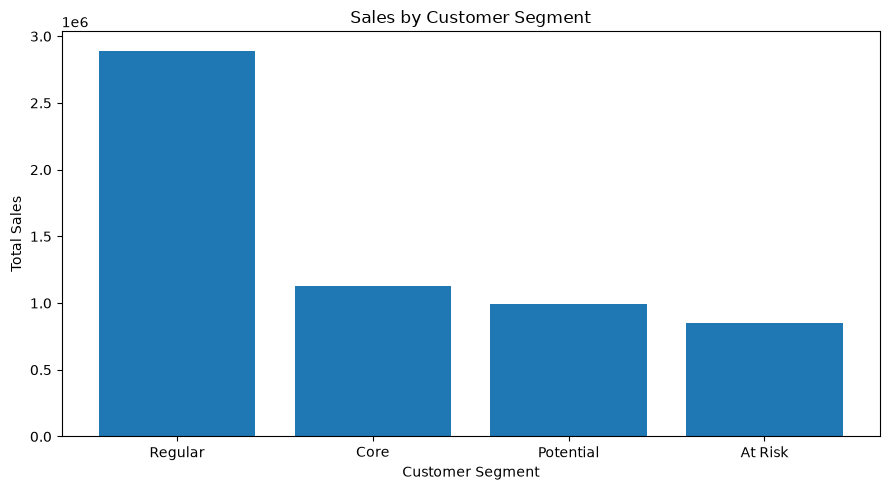

In [186]:
segment_plot = (
    segment_analysis
    .sort_values(
        "sales",
        ascending=False
    )
)

plt.figure(figsize=(9, 5))

plt.bar(
    segment_plot.index,
    segment_plot["sales"]
)

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [192]:
total_sales = df["total_amount"].sum()

print(f"总销售额：{total_sales:,.2f}")

total_orders = df["order_id"].nunique()
total_customers = df["customer_id"].nunique()

print(f"总订单数：{total_orders:,}")
print(f"总客户数：{total_customers:,}")

aov = total_sales / total_orders

print(f"客单价：{aov:.2f}")

total_profit = df["profit_margin"].sum()

profit_rate = (
    total_profit
    / total_sales
)

print(f"总利润：{total_profit:,.2f}")
print(f"整体利润率：{profit_rate:.2%}")

return_rate = (
    df["returned"]
    .eq("Yes")
    .mean()
)

print(f"退货率：{return_rate:.2%}")

customer_order_counts = (
    df.groupby("customer_id")["order_id"]
      .nunique()
)

repeat_rate = (
    customer_order_counts >= 2
).mean()

print(f"观察期复购率：{repeat_rate:.2%}")

总销售额：5,865,293.05
总订单数：34,500
总客户数：7,903
客单价：170.01
总利润：970,019.41
整体利润率：16.54%
退货率：5.52%
观察期复购率：93.99%


In [193]:
kpi_summary = pd.DataFrame({
    "metric": [
        "Total Sales",
        "Total Orders",
        "Total Customers",
        "AOV",
        "Total Profit",
        "Profit Rate",
        "Return Rate",
        "Repeat Rate"
    ],

    "value": [
        total_sales,
        total_orders,
        total_customers,
        aov,
        total_profit,
        profit_rate,
        return_rate,
        repeat_rate
    ]
})

kpi_summary

,metric,value
0,Total Sales,5.865293e+06
1,Total Orders,3.450000e+04
2,Total Customers,7.903000e+03
3,AOV,1.700085e+02
4,Total Profit,9.700194e+05
5,Profit Rate,1.653829e-01
6,Return Rate,5.515942e-02
7,Repeat Rate,9.398962e-01


In [194]:
kpi_display = kpi_summary.copy()

kpi_display["value"] = [
    f"{total_sales:,.2f}",
    f"{total_orders:,}",
    f"{total_customers:,}",
    f"{aov:.2f}",
    f"{total_profit:,.2f}",
    f"{profit_rate:.2%}",
    f"{return_rate:.2%}",
    f"{repeat_rate:.2%}"
]

kpi_display

,metric,value
0,Total Sales,"5,865,293.05"
1,Total Orders,"34,500"
2,Total Customers,"7,903"
3,AOV,170.01
4,Total Profit,"970,019.41"
5,Profit Rate,16.54%
6,Return Rate,5.52%
7,Repeat Rate,93.99%


In [195]:
print(
    "total_amount合计：",
    df["total_amount"].sum()
)

print(
    "客户表消费合计：",
    customer_analysis["total_spend"].sum()
)

print(
    "差额：",
    df["total_amount"].sum()
    - customer_analysis["total_spend"].sum()
)

total_amount合计： 5865293.05
客户表消费合计： 5865293.05
差额： 0.0


退货率：5.52%


In [ ]:
customer_order_counts = (
    df.groupby("customer_id")["order_id"]
      .nunique()
)

repeat_rate = (
    customer_order_counts >= 2
).mean()

print(f"观察期复购率：{repeat_rate:.2%}")

In [196]:
tables_to_check = [
    "monthly_analysis",
    "category_analysis",
    "region_analysis",
    "customer_analysis",
    "segment_analysis",
    "kpi_summary"
]

for name in tables_to_check:
    if name in globals():
        table = globals()[name]
        print(
            f"{name:<20}"
            f"行数：{table.shape[0]:>6}  "
            f"列数：{table.shape[1]:>3}"
        )
    else:
        print(f"{name:<20} 未找到")

monthly_analysis    行数：    25  列数：  3
category_analysis   行数：     7  列数： 12
region_analysis     行数：     5  列数： 11
customer_analysis   行数：  7903  列数： 12
segment_analysis    行数：     4  列数：  7
kpi_summary         行数：     8  列数：  2


In [197]:
print("df shape:", df.shape)

df.info()


df shape: (34500, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            34500 non-null  object        
 1   customer_id         34500 non-null  object        
 2   product_id          34500 non-null  object        
 3   category            34500 non-null  object        
 4   price               34500 non-null  float64       
 5   discount            34500 non-null  float64       
 6   quantity            34500 non-null  int64         
 7   payment_method      34500 non-null  object        
 8   order_date          34500 non-null  datetime64[ns]
 9   delivery_time_days  34500 non-null  int64         
 10  region              34500 non-null  object        
 11  returned            34500 non-null  object        
 12  total_amount        34500 non-null  float64       
 13  shipping_cost       3450

In [198]:
df.columns.tolist()


['order_id',
 'customer_id',
 'product_id',
 'category',
 'price',
 'discount',
 'quantity',
 'payment_method',
 'order_date',
 'delivery_time_days',
 'region',
 'returned',
 'total_amount',
 'shipping_cost',
 'profit_margin',
 'customer_age',
 'customer_gender',
 'year_month',
 'is_returned',
 'delivery_group',
 'age_group']

In [200]:
excel_data = df.copy()

excel_data["order_year"] = (
    excel_data["order_date"].dt.year
)

excel_data["order_month"] = (
    excel_data["order_date"].dt.month
)

excel_data.shape

(34500, 23)

In [201]:
excel_columns = [
    # ID
    "order_id",
    "customer_id",
    "product_id",

    # 时间
    "order_date",
    "order_year",
    "order_month",
    "year_month",

    # 商品
    "category",
    "price",
    "discount",
    "quantity",

    # 订单金额
    "total_amount",
    "shipping_cost",
    "profit_margin",

    # 支付
    "payment_method",

    # 履约与售后
    "delivery_time_days",
    "delivery_group",
    "returned",
    "is_returned",

    # 地区
    "region",

    # 客户
    "customer_age",
    "age_group",
    "customer_gender"
]

excel_data = excel_data[excel_columns]

In [202]:
excel_data.head()

,order_id,customer_id,product_id,order_date,order_year,order_month,year_month,category,price,discount,...,profit_margin,payment_method,delivery_time_days,delivery_group,returned,is_returned,region,customer_age,age_group,customer_gender
0,O100000,C17270,P234890,2023-12-23,2023,12,2023-12,Home,164.08,0.15,...,31.17,Credit Card,4,Fast,No,False,West,60,56-70,Female
1,O100001,C17603,P228204,2025-04-03,2025,4,2025-04,Grocery,24.73,0.00,...,-2.62,Credit Card,6,Normal,No,False,South,37,36-45,Male
2,O100002,C10860,P213892,2024-10-08,2024,10,2024-10,Electronics,175.58,0.05,...,13.44,Credit Card,4,Fast,No,False,North,34,26-35,Male
3,O100003,C15390,P208689,2024-09-14,2024,9,2024-09,Electronics,63.67,0.00,...,2.14,UPI,6,Normal,No,False,South,21,18-25,Female
4,O100004,C15226,P228063,2024-12-21,2024,12,2024-12,Home,16.33,0.15,...,1.15,COD,6,Normal,No,False,East,39,36-45,Male


In [204]:
excel_data["age_group"] = (
    excel_data["age_group"].astype(str)
)

excel_data["year_month"] = (
    excel_data["year_month"].astype(str)
)

In [205]:
monthly_excel = monthly_analysis.reset_index()
category_excel = category_analysis.reset_index()
region_excel = region_analysis.reset_index()
customer_excel = customer_analysis.reset_index()
segment_excel = segment_analysis.reset_index()
kpi_excel = kpi_summary.copy()


In [206]:
category_excel.head()

,category,sales,orders,units,profit,sales_share,aov,profit_rate,return_rate,units_per_order,avg_shipping,shipping_burden,profit_per_order
0,Electronics,3319206.50,6180,9343,344371.77,56.590634,537.088430,0.103751,0.072977,1.511812,8.727034,0.016249,55.723587
1,Home,1077681.52,5487,8229,262633.70,18.373873,196.406328,0.243703,0.056497,1.499727,7.129098,0.036298,47.864717
2,Sports,629825.54,4171,6244,160521.41,10.738177,151.001088,0.254866,0.049389,1.497003,6.815052,0.045132,38.485114
3,Fashion,471545.80,6254,9148,128814.65,8.039595,75.399073,0.273175,0.082827,1.462744,5.792328,0.076822,20.597162
4,Beauty,153019.38,4103,6122,49196.59,2.608896,37.294511,0.321506,0.037777,1.492079,4.792237,0.128497,11.990395


In [207]:
excel_tables = {
    "clean_data": excel_data,
    "monthly_analysis": monthly_excel,
    "category_analysis": category_excel,
    "region_analysis": region_excel,
    "customer_analysis": customer_excel,
    "segment_analysis": segment_excel,
    "kpi_summary": kpi_excel
}

for name, table in excel_tables.items():
    print(
        f"{name:<20}",
        table.shape
    )

clean_data           (34500, 23)
monthly_analysis     (25, 4)
category_analysis    (7, 13)
region_analysis      (5, 12)
customer_analysis    (7903, 13)
segment_analysis     (4, 8)
kpi_summary          (8, 2)


In [209]:
%pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpy


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [210]:
import openpyxl

print(openpyxl.__version__)

3.1.5


In [211]:
output_file = "ecommerce_operations_analysis.xlsx"

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    excel_data.to_excel(
        writer,
        sheet_name="clean_data",
        index=False
    )

    kpi_excel.to_excel(
        writer,
        sheet_name="KPI",
        index=False
    )

    monthly_excel.to_excel(
        writer,
        sheet_name="monthly",
        index=False
    )

    category_excel.to_excel(
        writer,
        sheet_name="category",
        index=False
    )

    region_excel.to_excel(
        writer,
        sheet_name="region",
        index=False
    )

    customer_excel.to_excel(
        writer,
        sheet_name="customer",
        index=False
    )

    segment_excel.to_excel(
        writer,
        sheet_name="segment",
        index=False
    )

print("Excel 导出完成：", output_file)

Excel 导出完成： ecommerce_operations_analysis.xlsx


In [212]:
xls = pd.ExcelFile(output_file)

xls.sheet_names

['clean_data', 'KPI', 'monthly', 'category', 'region', 'customer', 'segment']

In [213]:
check_data = pd.read_excel(
    output_file,
    sheet_name="clean_data"
)

check_data.shape

(34500, 23)